In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import sys, os, time

sys.path.append('packages')

import crydberg as rd

In [2]:
# Program variables
# task_id=int(sys.argv[1]) - 1 # for SLURM_ARRAY_TASK_ID
N=10
T_low=0
T_high=1
n_T=11
n_steps_burn=20000
n_steps_history=1
n_samples_thermal=100
n_samples_parallel=100
n_samples_internal=1
n_samples_external=1
precession=0
K=1
dt=0.1
dir_sys='data/226'

# Additional system parameters
B0 = 0
B0_theta = 0
B0_phi = 0

# Thermodynamic parameters and indexing scheme
T_vals = np.linspace(T_low, T_high, n_T)
T_idcs = np.arange(len(T_vals))
sample_idcs = np.arange(n_samples_external)
sample_idcs, T_idcs = np.meshgrid(sample_idcs, T_idcs)
sample_idcs, T_idcs = sample_idcs.flatten(), T_idcs.flatten()

# Additional dynamics parameters
alpha = 1

# number of parallel samples in one MagneticSystem instance
n_samples = n_samples_parallel*n_samples_thermal # total number of samples computed in parallel in one GPU

# number of tasks
n_task = n_T*n_samples_external 

In [3]:
for task_id in range(n_task):
    start_time = time.time()
    T_idx = T_idcs[task_id]
    sample_idx = sample_idcs[task_id]
    T = T_vals[T_idx]
    
    # File tag
    tag = str(T_idx) + '_' + str(sample_idx)
    
    # running simulation for each internalSample sequentially
    for internalSample_idx in range(n_samples_internal):
        systems = rd.MagneticSystem(N, n_samples, K=K) # generating system
        systems.align_m() # randomizing initial spin config. m0
        systems.m = cp.broadcast_to(systems.m[0], (n_samples, N, 3)) # copying one m0 throughout all samples
        np.save(f'{dir_sys}/m0_T{T_idx}.npy', systems.m.get()) # saving m0

        # setting Js of thermal samples batches with one J
        J_toSet = []
        for J in systems.J[:n_samples_parallel]:
            J_toSet.append(cp.broadcast_to(J, (n_samples_thermal, N, N)))
        J_toSet = cp.array(J_toSet)
        J_toSet = J_toSet.reshape(n_samples, N, N)
        systems.J = J_toSet
        del J_toSet # deleting buffer
        np.save(f'{dir_sys}/J_T{T_idx}.npy', systems.J.get()) # saving coupling matrices
    
        # burning-in system
        for i in range(n_steps_burn):
            systems.LLG_1stepSIB(dt, alpha=1, precession=0, T=T)
            print(f'\rProgress: {100*i/n_steps_burn}%     ', end='')
        
        # storing data
        history = []
        for i in range(n_steps_history):
            history.append(systems.m)
            systems.LLG_1stepSIB(dt, alpha=1, precession=0, T=T)
        history = cp.array(history).reshape(n_steps_history, n_samples_parallel, n_samples_thermal, N, 3)
        np.save(f'{dir_sys}/history_T{T_idx}.npy', history.get())
        print(f'\r{T_idx + 1}/{T_vals.size} Done.          ')
    
    # Finishing and reporting elapsed time
    end_time = np.round((time.time() - start_time)/3600,2)
    print(f'Simulation {tag} done. Time elapsed: {end_time} hrs.')

c:\Users\krlod\miniconda3\Lib\site-packages\numba_cuda\numba\cuda\dispatcher.py:748: NumbaPerformanceWarning: Grid size 98 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


1/11 Done.            
Simulation 0_0 done. Time elapsed: 0.04 hrs.
2/11 Done.            
Simulation 1_0 done. Time elapsed: 0.04 hrs.
3/11 Done.            
Simulation 2_0 done. Time elapsed: 0.04 hrs.
4/11 Done.            
Simulation 3_0 done. Time elapsed: 0.04 hrs.
5/11 Done.            
Simulation 4_0 done. Time elapsed: 0.04 hrs.
6/11 Done.            
Simulation 5_0 done. Time elapsed: 0.04 hrs.
7/11 Done.            
Simulation 6_0 done. Time elapsed: 0.04 hrs.
8/11 Done.            
Simulation 7_0 done. Time elapsed: 0.04 hrs.
9/11 Done.            
Simulation 8_0 done. Time elapsed: 0.04 hrs.
10/11 Done.           
Simulation 9_0 done. Time elapsed: 0.04 hrs.
11/11 Done.           
Simulation 10_0 done. Time elapsed: 0.04 hrs.


# Edwards-Anderson parameter

In [4]:
EA = []
for T_idx, T in enumerate(T_vals):
    history = np.load(f'{dir_sys}/history_T{T_idx}.npy')
    EA_T = np.mean(np.mean(history, axis=2)**2, axis=(0,1,2))
    EA.append(EA_T)
EA = np.array(EA)
np.save(f'{dir_sys}/EA_N{N}_K{K}.npy', EA)

EA2 = []
for T_idx, T in enumerate(T_vals):
    history = np.load(f'{dir_sys}/history_T{T_idx}.npy')
    EA2_T = np.mean(np.mean(history, axis=2)**4, axis=(0,1,2))
    EA2.append(EA2_T)
EA2 = np.array(EA2)
np.save(f'{dir_sys}/EA2_N{N}_K{K}.npy', EA2)

In [5]:
U = (3 - EA2/EA**2)/2
np.save(f'{dir_sys}/U_N{N}_K{K}.npy', U)

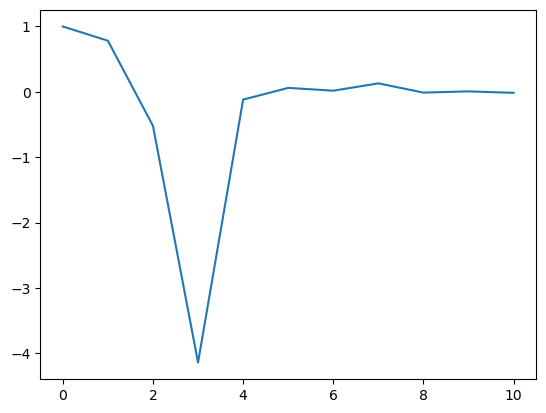

In [6]:
plt.plot(U[:,2])